In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
FILE_PATH = "Accident_Dataset.csv"
SAMPLE_SIZE = None                       
RANDOM_STATE = 42

In [3]:
print("Loading data...")
if SAMPLE_SIZE:
    df = pd.read_csv(FILE_PATH, nrows=SAMPLE_SIZE, low_memory=False)
else:
    df = pd.read_csv(FILE_PATH, low_memory=False)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")


Loading data...
Loaded 7,728,394 rows and 46 columns.


In [7]:
print("\nInitial Data Overview:")
print(df.info())


Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64

In [5]:
print("\nMissing values (top 10 columns):")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Missing values (top 10 columns):
End_Lat              3402762
End_Lng              3402762
Precipitation(in)    2203586
Wind_Chill(F)        1999019
Wind_Speed(mph)       571233
Visibility(mi)        177098
Wind_Direction        175206
Humidity(%)           174144
Weather_Condition     173459
Temperature(F)        163853
dtype: int64


In [6]:
print("\nNumeric columns summary:")
print(df.describe())


Numeric columns summary:
           Severity     Start_Lat     Start_Lng       End_Lat       End_Lng  \
count  7.728394e+06  7.728394e+06  7.728394e+06  4.325632e+06  4.325632e+06   
mean   2.212384e+00  3.620119e+01 -9.470255e+01  3.626183e+01 -9.572557e+01   
std    4.875313e-01  5.076079e+00  1.739176e+01  5.272905e+00  1.810793e+01   
min    1.000000e+00  2.455480e+01 -1.246238e+02  2.456601e+01 -1.245457e+02   
25%    2.000000e+00  3.339963e+01 -1.172194e+02  3.346207e+01 -1.177543e+02   
50%    2.000000e+00  3.582397e+01 -8.776662e+01  3.618349e+01 -8.802789e+01   
75%    2.000000e+00  4.008496e+01 -8.035368e+01  4.017892e+01 -8.024709e+01   
max    4.000000e+00  4.900220e+01 -6.711317e+01  4.907500e+01 -6.710924e+01   

       Distance(mi)  Temperature(F)  Wind_Chill(F)   Humidity(%)  \
count  7.728394e+06    7.564541e+06   5.729375e+06  7.554250e+06   
mean   5.618423e-01    6.166329e+01   5.825105e+01  6.483104e+01   
std    1.776811e+00    1.901365e+01   2.238983e+01  2.2820

In [8]:
print("\n Cleaning data...")


 Cleaning data...


In [9]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time']   = pd.to_datetime(df['End_Time'], errors='coerce')
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], errors='coerce')

In [14]:
df.dropna(subset=['Start_Lat', 'Start_Lng', 'Start_Time'], inplace=True)
print(f"Remaining rows: {df.shape[0]:,}")

Remaining rows: 6,985,228


In [16]:
initial_len = len(df)
df.drop_duplicates(subset=['ID'], inplace=True)
print(f"Removed {initial_len - len(df)} duplicate rows.")

Removed 0 duplicate rows.


In [17]:
numeric_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
                'Wind_Speed(mph)', 'Precipitation(in)', 'Wind_Chill(F)']
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

In [18]:
categorical_cols = ['Weather_Condition', 'Wind_Direction', 'Airport_Code', 'Street', 'County']
for col in categorical_cols:
    if col in df.columns:
        df[col].fillna('Unknown', inplace=True)

In [19]:
print(f"Data cleaning complete. Current shape: {df.shape[0]:,} rows, {df.shape[1]} columns.")

Data cleaning complete. Current shape: 6,985,228 rows, 46 columns.


In [20]:
print("\nCreating new features...")


Creating new features...


In [21]:
df['Hour'] = df['Start_Time'].dt.hour
df['Day_of_Week'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month
df['Year'] = df['Start_Time'].dt.year
df['Weekday_Flag'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)

In [22]:
df['Duration_Min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['Duration_Min'] = df['Duration_Min'].clip(lower=0, upper=1440)

In [23]:
infra_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
              'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
              'Traffic_Signal', 'Turning_Loop']
# Ensure these columns exist; if not, skip missing ones
existing_infra = [c for c in infra_cols if c in df.columns]
df['Infra_Count'] = df[existing_infra].fillna(0).astype(int).sum(axis=1)

In [24]:
top_weather = df['Weather_Condition'].value_counts().head(10).index
df['Weather_Grouped'] = df['Weather_Condition'].apply(lambda x: x if x in top_weather else 'Other')

In [25]:
df['Severity_Cat'] = df['Severity'].map({1: 'Minor', 2: 'Moderate', 3: 'Serious', 4: 'Severe'})

In [26]:
print("Feature engineering complete.")

Feature engineering complete.


In [28]:
print("\nStarting EDA and visualizations...")


Starting EDA and visualizations...


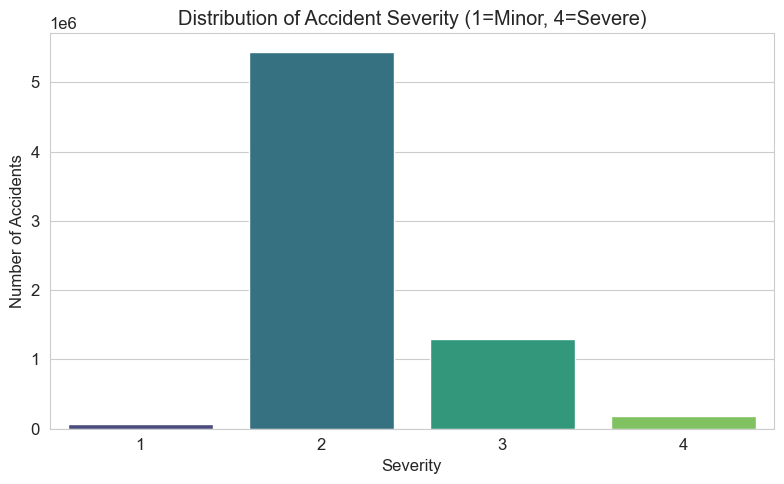

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Severity', palette='viridis')
plt.title('Distribution of Accident Severity (1=Minor, 4=Severe)')
plt.xlabel('Severity')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.savefig('01_severity_distribution.png')
plt.show()

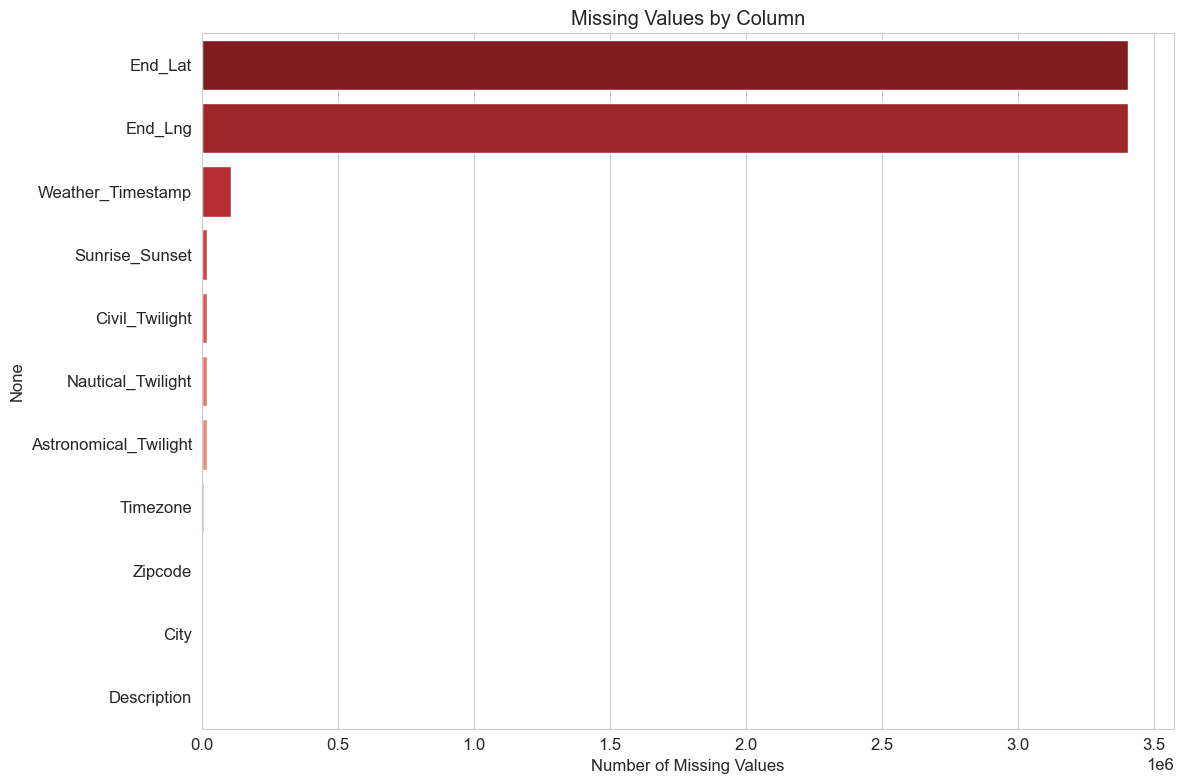

In [30]:
plt.figure(figsize=(12,8))
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if not missing.empty:
    sns.barplot(x=missing.values, y=missing.index, palette='Reds_r')
    plt.title('Missing Values by Column')
    plt.xlabel('Number of Missing Values')
    plt.tight_layout()
    plt.savefig('02_missing_values.png')
    plt.show()

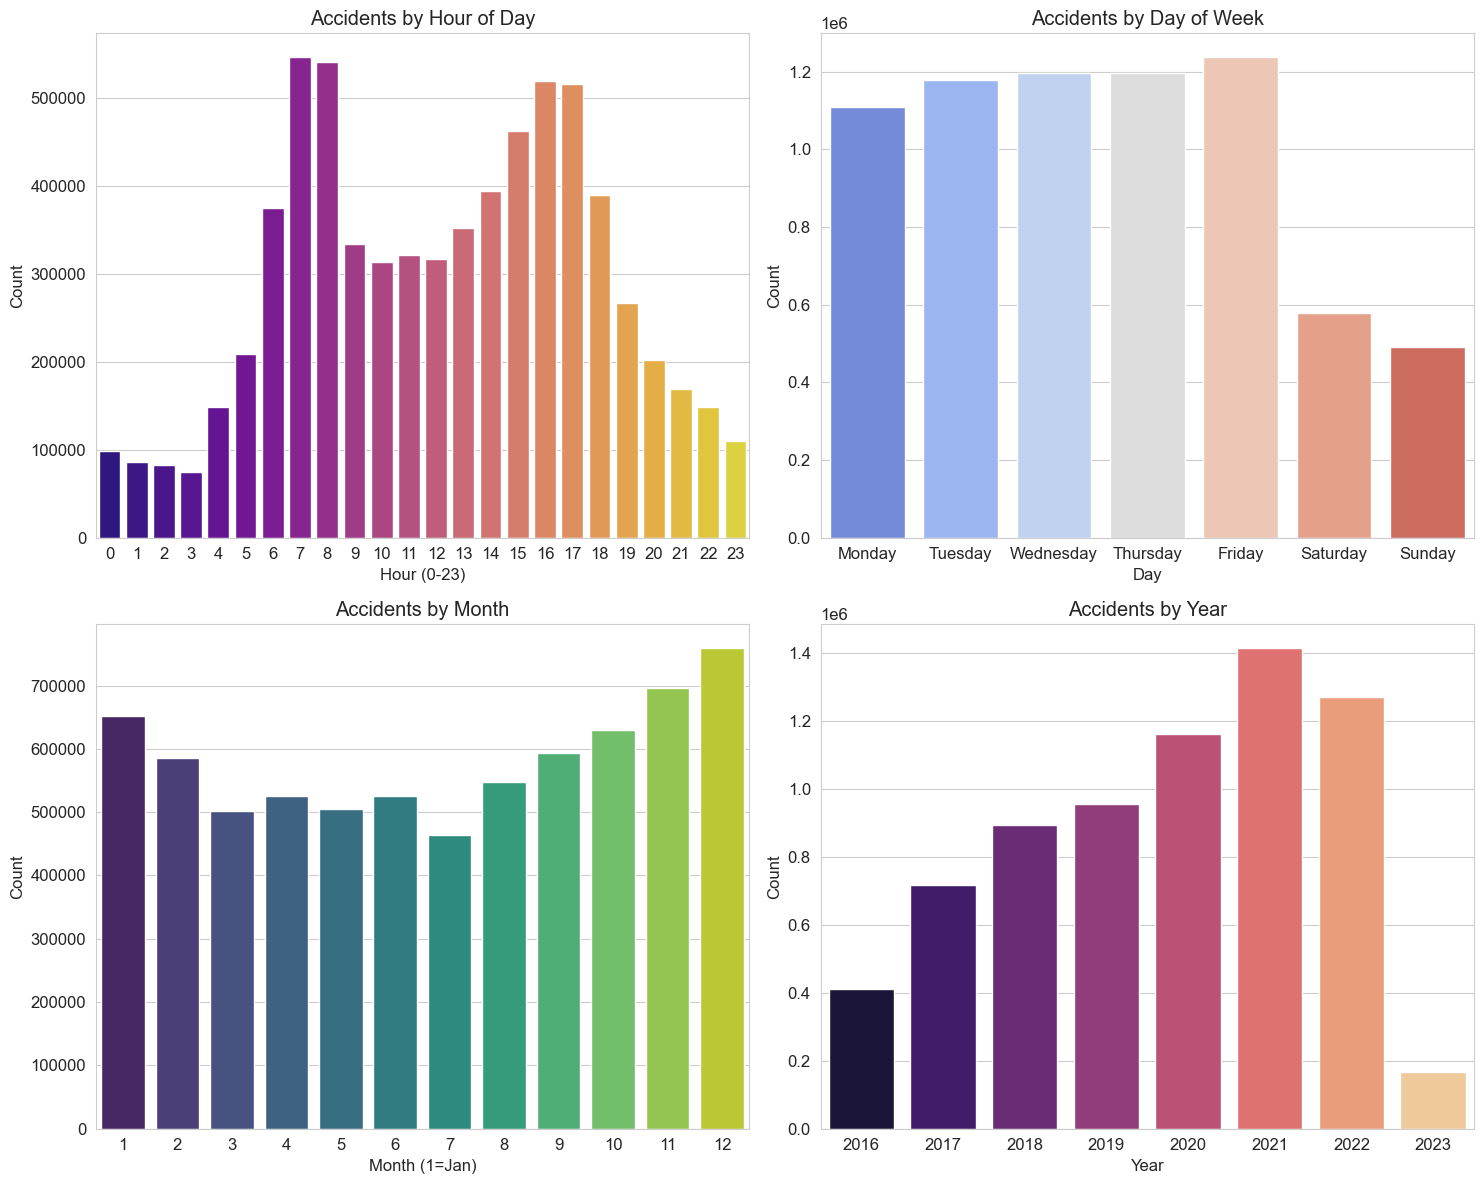

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Hour
hour_counts = df['Hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, ax=axes[0,0], palette='plasma')
axes[0,0].set_title('Accidents by Hour of Day')
axes[0,0].set_xlabel('Hour (0-23)')
axes[0,0].set_ylabel('Count')

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.countplot(data=df, x='Day_of_Week', order=day_order, ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title('Accidents by Day of Week')
axes[0,1].set_xlabel('Day')
axes[0,1].set_ylabel('Count')

# Month
month_counts = df['Month'].value_counts().sort_index()
sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Accidents by Month')
axes[1,0].set_xlabel('Month (1=Jan)')
axes[1,0].set_ylabel('Count')

# Year (if multiple)
year_counts = df['Year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, ax=axes[1,1], palette='magma')
axes[1,1].set_title('Accidents by Year')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('03_time_patterns.png')
plt.show()


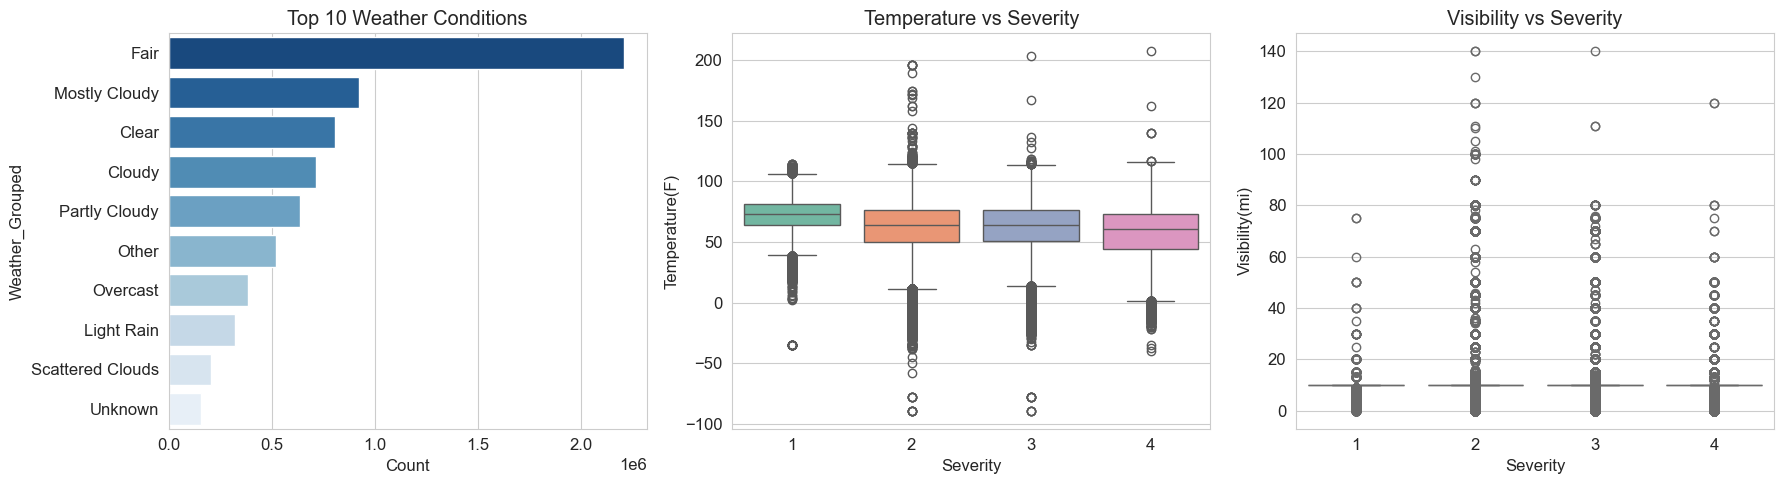

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top weather conditions
weather_top = df['Weather_Grouped'].value_counts().head(10)
sns.barplot(x=weather_top.values, y=weather_top.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Weather Conditions')
axes[0].set_xlabel('Count')

# Boxplot: Temperature vs Severity
sns.boxplot(data=df, x='Severity', y='Temperature(F)', ax=axes[1], palette='Set2')
axes[1].set_title('Temperature vs Severity')

# Boxplot: Visibility vs Severity
sns.boxplot(data=df, x='Severity', y='Visibility(mi)', ax=axes[2], palette='Set3')
axes[2].set_title('Visibility vs Severity')

plt.tight_layout()
plt.savefig('04_weather_analysis.png')
plt.show()

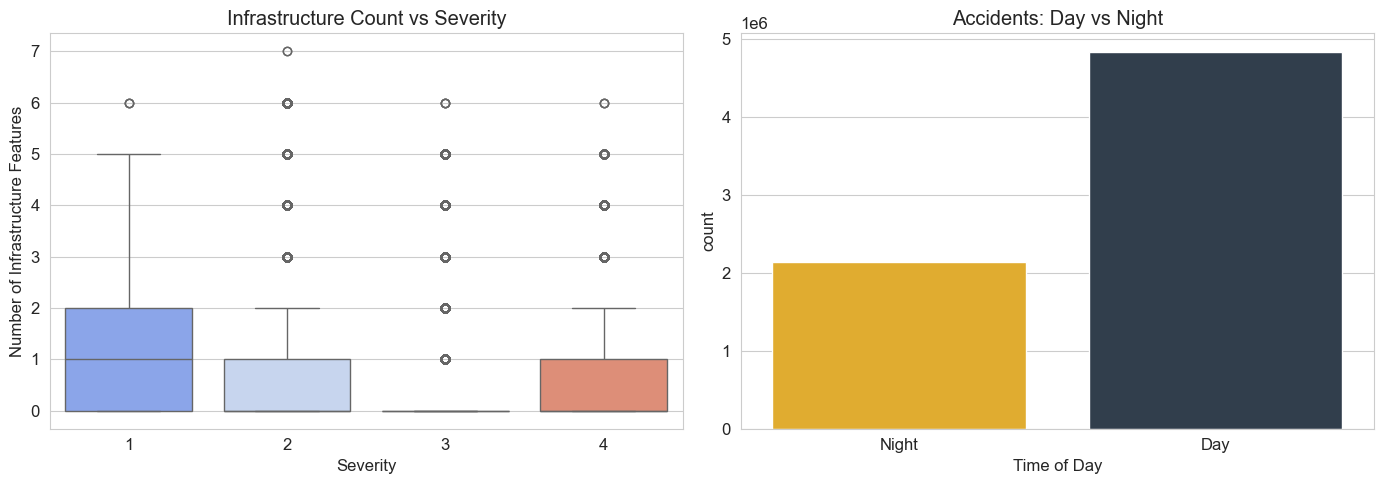

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Infra count vs Severity
sns.boxplot(data=df, x='Severity', y='Infra_Count', ax=axes[0], palette='coolwarm')
axes[0].set_title('Infrastructure Count vs Severity')
axes[0].set_ylabel('Number of Infrastructure Features')

# Day/Night comparison
sns.countplot(data=df, x='Sunrise_Sunset', ax=axes[1], palette=['#fdb813', '#2c3e50'])
axes[1].set_title('Accidents: Day vs Night')
axes[1].set_xlabel('Time of Day')

plt.tight_layout()
plt.savefig('05_infrastructure_analysis.png')
plt.show()

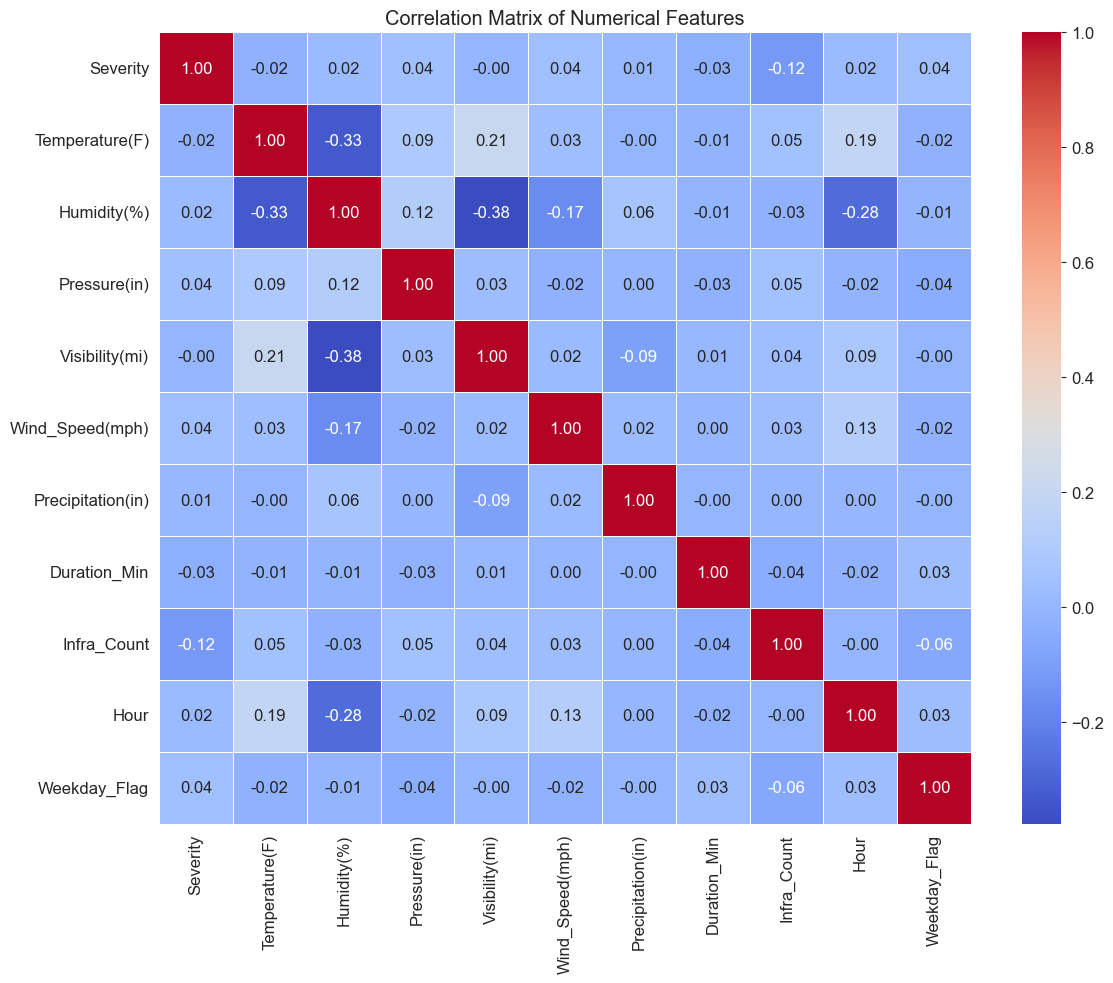

In [36]:
num_cols = ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
            'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
            'Duration_Min', 'Infra_Count', 'Hour', 'Weekday_Flag']
# Keep only columns that exist
num_cols_exist = [c for c in num_cols if c in df.columns]
corr = df[num_cols_exist].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png')
plt.show()

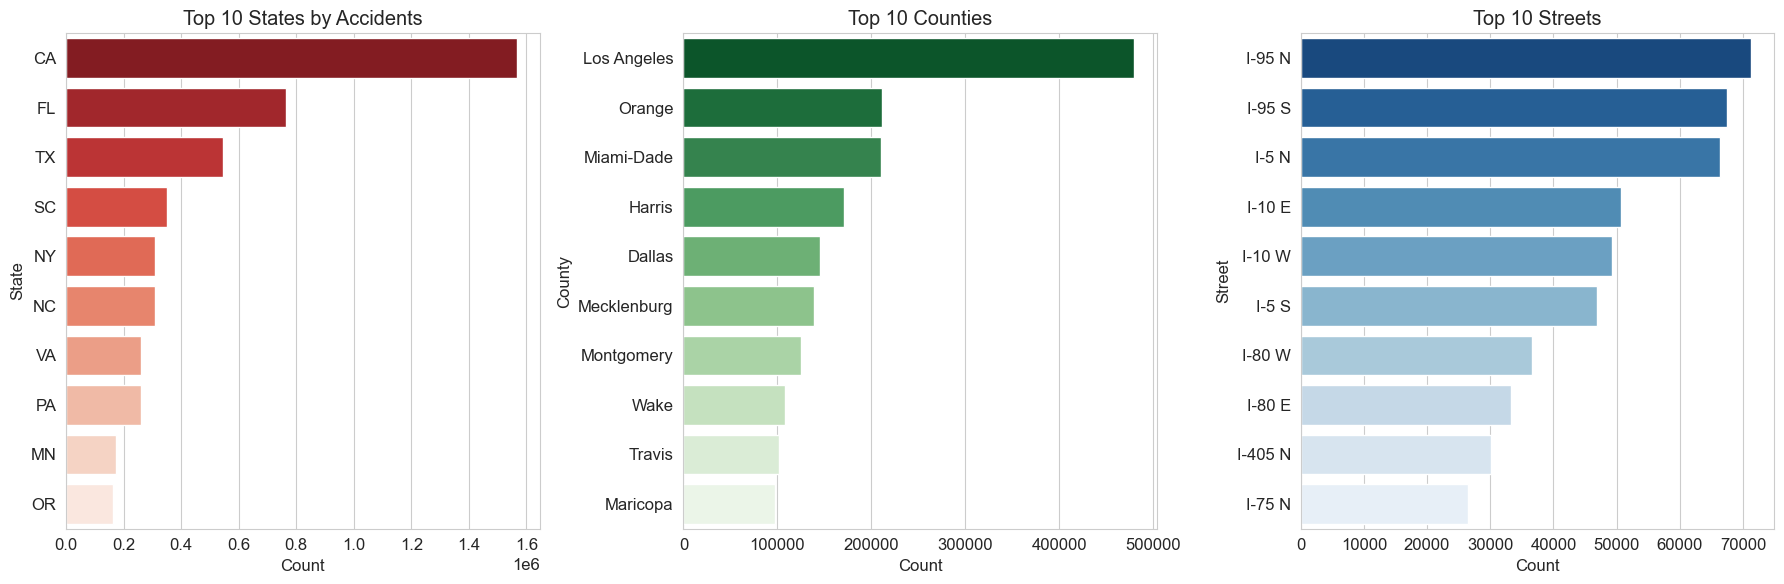

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# States
state_counts = df['State'].value_counts().head(10)
sns.barplot(x=state_counts.values, y=state_counts.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 States by Accidents')
axes[0].set_xlabel('Count')

# Counties
county_counts = df['County'].value_counts().head(10)
sns.barplot(x=county_counts.values, y=county_counts.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Counties')
axes[1].set_xlabel('Count')

# Streets
street_counts = df['Street'].value_counts().head(10)
sns.barplot(x=street_counts.values, y=street_counts.index, ax=axes[2], palette='Blues_r')
axes[2].set_title('Top 10 Streets')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('07_top_locations.png')
plt.show()

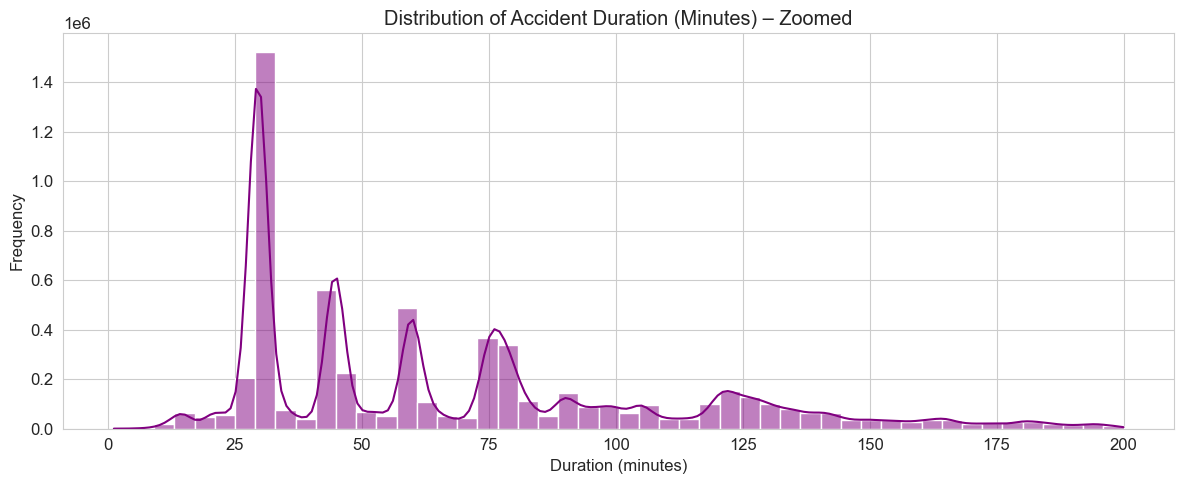

In [38]:
plt.figure(figsize=(12,5))
duration_filtered = df[(df['Duration_Min'] >= 1) & (df['Duration_Min'] <= 200)]['Duration_Min']
sns.histplot(duration_filtered, bins=50, kde=True, color='purple')
plt.title('Distribution of Accident Duration (Minutes) – Zoomed')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('08_duration_distribution.png')
plt.show()

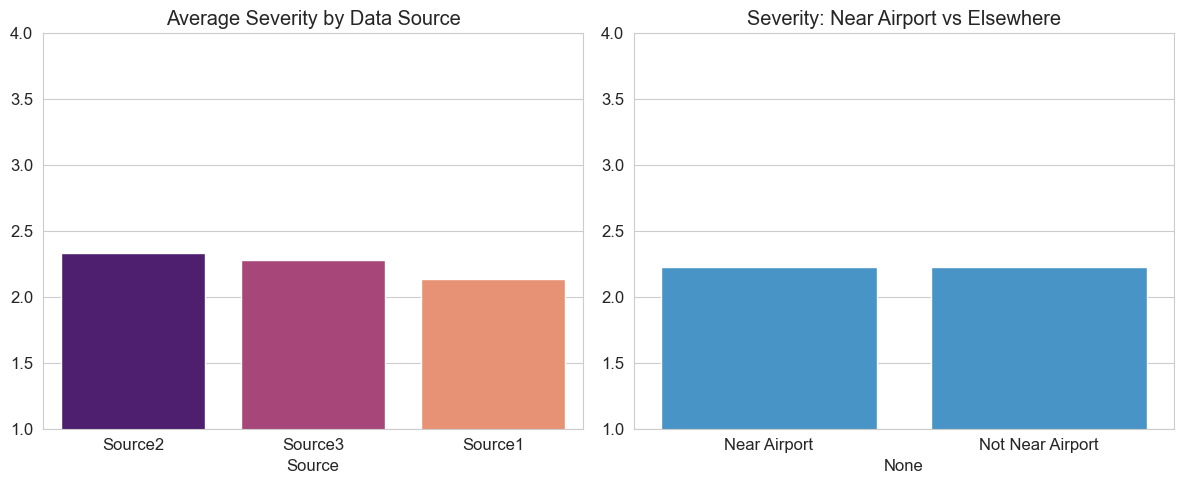

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Source vs Severity
if 'Source' in df.columns:
    source_sev = df.groupby('Source')['Severity'].mean().sort_values(ascending=False)
    sns.barplot(x=source_sev.index, y=source_sev.values, ax=axes[0], palette='magma')
    axes[0].set_title('Average Severity by Data Source')
    axes[0].set_ylim(1, 4)

# Airport vs Non-Airport
if 'Airport_Code' in df.columns:
    airport_avg = df.groupby(df['Airport_Code'].notna())['Severity'].mean()
    airport_avg.index = ['Near Airport'] 
    sns.barplot(x=airport_avg.index, y=airport_avg.values, ax=axes[1], palette=['#3498db','#e74c3c'])
    axes[1].set_title('Severity: Near Airport vs Elsewhere')
    axes[1].set_ylim(1, 4)

if 'Airport_Code' in df.columns:
    airport_avg = df.groupby(df['Airport_Code'].notna())['Severity'].mean()
    airport_avg.index = ['Not Near Airport'] 
    sns.barplot(x=airport_avg.index, y=airport_avg.values, ax=axes[1], palette=['#3498db','#e74c3c'])
    axes[1].set_title('Severity: Near Airport vs Elsewhere')
    axes[1].set_ylim(1, 4)

plt.tight_layout()
plt.savefig('09_source_airport_analysis.png')
plt.show()

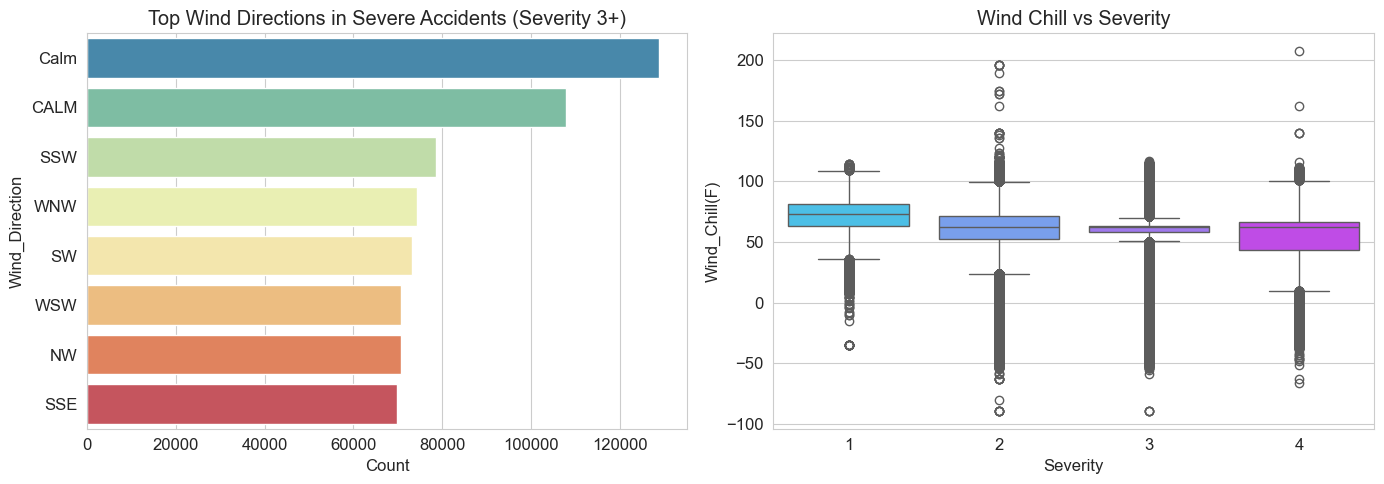

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Wind_Direction' in df.columns and 'Severity' in df.columns:
    severe_df = df[df['Severity'] >= 3]
    wind_dir = severe_df['Wind_Direction'].value_counts().head(8)
    sns.barplot(x=wind_dir.values, y=wind_dir.index, ax=axes[0], palette='Spectral_r')
    axes[0].set_title('Top Wind Directions in Severe Accidents (Severity 3+)')
    axes[0].set_xlabel('Count')

if 'Wind_Chill(F)' in df.columns:
    sns.boxplot(data=df, x='Severity', y='Wind_Chill(F)', ax=axes[1], palette='cool')
    axes[1].set_title('Wind Chill vs Severity')

plt.tight_layout()
plt.savefig('10_wind_analysis.png')
plt.show()

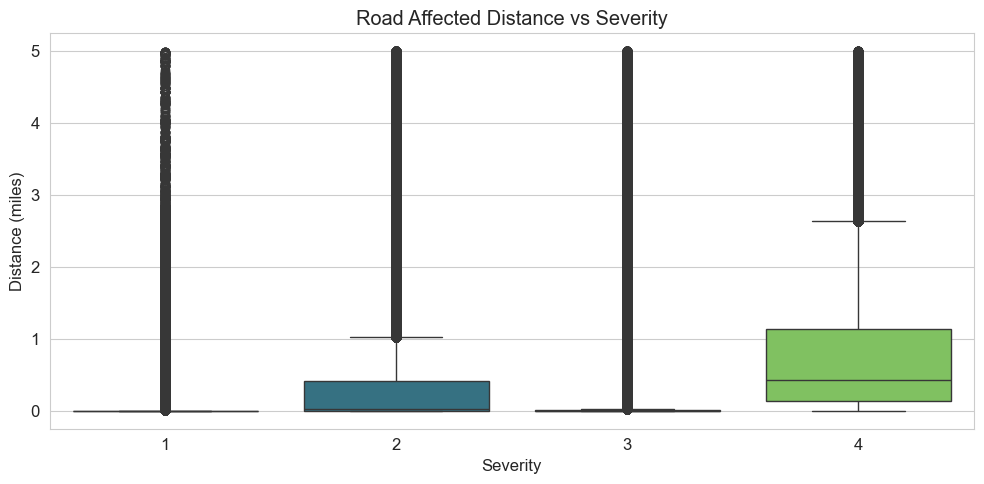

In [48]:
if 'Distance(mi)' in df.columns:
    plt.figure(figsize=(10,5))
    dist_clean = df[df['Distance(mi)'] <= 5]  
    sns.boxplot(data=dist_clean, x='Severity', y='Distance(mi)', palette='viridis')
    plt.title('Road Affected Distance vs Severity')
    plt.xlabel('Severity')
    plt.ylabel('Distance (miles)')
    plt.tight_layout()
    plt.savefig('11_distance_vs_severity.png')
    plt.show()

In [50]:
print("\nGenerating interactive hotspot map (sampling 10,000 points)...")
sample_map = df.sample(n=min(10000, len(df)), random_state=RANDOM_STATE).dropna(subset=['Start_Lat', 'Start_Lng'])
m = folium.Map(location=[39.8, -98.5], zoom_start=4, tiles='CartoDB positron')
heat_data = [[row['Start_Lat'], row['Start_Lng']] for _, row in sample_map.iterrows()]
HeatMap(heat_data, radius=10, blur=15, max_zoom=1).add_to(m)
m.save('12_hotspot_map.html')
print("Saved '12_hotspot_map.html' – open in browser.")


Generating interactive hotspot map (sampling 10,000 points)...
Saved '12_hotspot_map.html' – open in browser.


In [51]:
fig = px.scatter(
    sample_map.sample(5000, random_state=RANDOM_STATE),
    x='Temperature(F)', y='Visibility(mi)',
    color='Severity', hover_data=['City', 'State', 'Weather_Condition'],
    title='Severity vs Temperature & Visibility'
)
fig.write_html('13_scatter_plotly.html')
print("Saved '13_scatter_plotly.html' – open in browser.")


Saved '13_scatter_plotly.html' – open in browser.


In [52]:
print("\nDeep dive – grouping by key factors...")


Deep dive – grouping by key factors...


In [55]:
weather_sev = df.groupby('Weather_Grouped')['Severity'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 weather conditions with highest average severity:")
print(weather_sev)


Top 10 weather conditions with highest average severity:
Weather_Grouped
Overcast            2.385400
Scattered Clouds    2.380390
Clear               2.368019
Light Snow          2.272449
Unknown             2.272208
Light Rain          2.266422
Mostly Cloudy       2.240229
Partly Cloudy       2.234954
Other               2.226225
Cloudy              2.173938
Name: Severity, dtype: float64


In [56]:
day_sev = df.groupby('Day_of_Week')['Severity'].mean().reindex(day_order)
print("\nAverage severity by day of week:")
print(day_sev)


Average severity by day of week:
Day_of_Week
Monday       2.223056
Tuesday      2.219721
Wednesday    2.217490
Thursday     2.218897
Friday       2.223169
Saturday     2.269822
Sunday       2.287508
Name: Severity, dtype: float64


In [58]:
hour_sev = df.groupby('Hour')['Severity'].mean()
peak_hour_sev = hour_sev.idxmax()
print(f"\nHour with highest average severity: {peak_hour_sev}:00 (avg {hour_sev.max():.2f})")


Hour with highest average severity: 20:00 (avg 2.27)


In [59]:
print(f"\nCorrelation between Infrastructure Count and Severity: {df['Infra_Count'].corr(df['Severity']):.3f}")


Correlation between Infrastructure Count and Severity: -0.120


In [60]:
dur_sev = df.groupby('Severity')['Duration_Min'].median()
print("\nMedian accident duration by severity:")
print(dur_sev)



Median accident duration by severity:
Severity
1     44.750000
2     75.716667
3     44.400000
4    130.183333
Name: Duration_Min, dtype: float64


In [61]:
print("\n" + "="*30)
print(" PROJECT SUMMARY")
print("="*30)

print(f"Total accidents analyzed: {df.shape[0]:,}")
print(f"Date range: {df['Start_Time'].min()} to {df['Start_Time'].max()}")
print(f"States covered: {df['State'].nunique()}")
print(f"Most common weather: {df['Weather_Condition'].mode()[0]}")
print(f"Peak accident hour: {df['Hour'].mode()[0]}:00")
print(f"Day with most accidents: {df['Day_of_Week'].mode()[0]}")
print(f"Most dangerous state: {df['State'].value_counts().idxmax()} ({df['State'].value_counts().max():,} accidents)")
print(f"Most dangerous county: {df['County'].value_counts().idxmax()}")
print(f"Average severity: {df['Severity'].mean():.2f} (on scale 1-4)")
print(f"Percentage of severe accidents (Severity 3 & 4): {((df['Severity'] >= 3).mean()*100):.1f}%")
print(f"Average duration: {df['Duration_Min'].mean():.1f} minutes (median: {df['Duration_Min'].median():.1f})")

print("\nAll visualizations have been saved in the current directory.")
print("Project analysis complete!")


 PROJECT SUMMARY
Total accidents analyzed: 6,985,228
Date range: 2016-01-14 20:18:33 to 2023-03-31 23:30:00
States covered: 49
Most common weather: Fair
Peak accident hour: 7:00
Day with most accidents: Friday
Most dangerous state: CA (1,567,136 accidents)
Most dangerous county: Los Angeles
Average severity: 2.23 (on scale 1-4)
Percentage of severe accidents (Severity 3 & 4): 21.2%
Average duration: 111.5 minutes (median: 62.7)

All visualizations have been saved in the current directory.
Project analysis complete!
